In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout 
from imblearn.over_sampling import SMOTE
from keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

In [2]:
device = pd.read_csv(r'H:\dataset cert\r4.2\device.csv')
logon = pd.read_csv(r'H:\dataset cert\r4.2\logon.csv')
http = pd.read_csv(r'h:\dataset cert\r4.2\http.csv')
file = pd.read_csv(r'H:\dataset cert\r4.2\file.csv')
threats_df = pd.read_csv(r'h:\dataset cert\answers\answers\insiders.csv')

In [3]:
print("Converting dates...")

logon['date'] = pd.to_datetime(logon['date'])
device['date'] = pd.to_datetime(device['date'])
http['date'] = pd.to_datetime(http['date'])
file['date'] = pd.to_datetime(file['date'])

print("Dates converted successfully")

Converting dates...
Dates converted successfully


In [4]:
print("Extracting logon features...")

logon_features = logon.groupby([logon['user'], logon['date'].dt.date]).agg(
    total_logons=('id', 'count'),
    avg_logon_hour=('date', lambda x: x.dt.hour.mean()),
    std_logon_hour=('date', lambda x: x.dt.hour.std()),
    weekend_logons=('date', lambda x: (x.dt.dayofweek >= 5).sum()),
    after_hours_logons=('date', lambda x: ((x.dt.hour < 8) | (x.dt.hour > 18)).sum()),
    unique_pcs_logon=('pc', 'nunique')
).reset_index()

logon_features.columns = ['user', 'date', 'total_logons', 'avg_logon_hour', 
                          'std_logon_hour', 'weekend_logons', 'after_hours_logons', 
                          'unique_pcs_logon']

print(f" Logon features: {logon_features.shape}")
print(logon_features.head())

Extracting logon features...
 Logon features: (15322, 8)
      user        date  total_logons  avg_logon_hour  std_logon_hour  \
0  AAE0190  2010-01-04             2            13.0        7.071068   
1  AAE0190  2010-01-05             2            13.0        7.071068   
2  AAE0190  2010-01-06             2            13.0        7.071068   
3  AAE0190  2010-01-07             2            13.0        7.071068   
4  AAE0190  2010-01-08             2            13.0        7.071068   

   weekend_logons  after_hours_logons  unique_pcs_logon  
0               0                   0                 1  
1               0                   0                 1  
2               0                   0                 1  
3               0                   0                 1  
4               0                   0                 1  


In [5]:
print("\nExtracting device features...")

device_features = device.groupby([device['user'], device['date'].dt.date]).agg(
    total_device_activities=('id', 'count'),
    device_connects=('activity', lambda x: (x == 'Connect').sum() if 'activity' in device.columns else 0),
    device_disconnects=('activity', lambda x: (x == 'Disconnect').sum() if 'activity' in device.columns else 0),
    unique_pcs_device=('pc', 'nunique'),
    avg_device_hour=('date', lambda x: x.dt.hour.mean()),
    after_hours_device=('date', lambda x: ((x.dt.hour < 8) | (x.dt.hour > 18)).sum())
).reset_index()

device_features.columns = ['user', 'date', 'total_device_activities', 'device_connects',
                           'device_disconnects', 'unique_pcs_device', 'avg_device_hour',
                           'after_hours_device']

print(f" Device features: {device_features.shape}")
print(device_features.head())


Extracting device features...
 Device features: (5643, 8)
      user        date  total_device_activities  device_connects  \
0  AAF0535  2010-01-05                        4                2   
1  AAF0535  2010-01-06                        2                1   
2  AAF0535  2010-01-07                        4                2   
3  AAF0535  2010-01-08                        8                4   
4  AAF0535  2010-01-11                        2                1   

   device_disconnects  unique_pcs_device  avg_device_hour  after_hours_device  
0                   2                  1            13.25                   0  
1                   1                  1            14.50                   0  
2                   2                  1            12.00                   0  
3                   4                  1            13.00                   0  
4                   1                  1            12.00                   0  


In [6]:
print("\nExtracting http features...")

http['domain'] = http['url'].str.extract(r'https?://(?:www\.)?([^/]+)')

domain_counts = http['domain'].value_counts()
rare_domains_list = domain_counts[domain_counts <= 3].index.tolist()

http_features = http.groupby([http['user'], http['date'].dt.date]).agg(
    total_http=('id', 'count'),
    unique_domains=('domain', 'nunique'),
    rare_domains=('domain', lambda x: x.isin(rare_domains_list).sum()),
    late_http=('date', lambda x: ((x.dt.hour >= 0) & (x.dt.hour <= 5)).sum()),
    sensitive_http=('content', lambda x: x.str.contains('password|login|admin|confidential', case=False, na=False).sum() if 'content' in http.columns else 0)
).reset_index()

http_features.columns = ['user', 'date', 'total_http', 'unique_domains', 
                         'rare_domains', 'late_http', 'sensitive_http']

print(f"HTTP features: {http_features.shape}")
print(http_features.head())


Extracting http features...
HTTP features: (1100, 7)
      user        date  total_http  unique_domains  rare_domains  late_http  \
0  AAE0190  2010-01-04          66              36             0          0   
1  AAF0535  2010-01-04          12               9             0          0   
2  AAF0791  2010-01-04          44              26             0          0   
3  AAL0706  2010-01-04           4               4             0          0   
4  AAM0658  2010-01-04          11              10             0          0   

   sensitive_http  
0               2  
1               0  
2               1  
3               0  
4               0  


In [7]:
print("\nExtracting file features...")

file['file_ext'] = file['filename'].str.extract(r'\.([^.]+)$')

file_features = file.groupby([file['user'], file['date'].dt.date]).agg(
    total_file_activities=('id', 'count'),
    unique_files=('filename', 'nunique'),
    unique_pcs_file=('pc', 'nunique'),
    avg_file_hour=('date', lambda x: x.dt.hour.mean()),
    after_hours_files=('date', lambda x: ((x.dt.hour < 8) | (x.dt.hour > 18)).sum()),
    exe_files=('file_ext', lambda x: x.str.contains('exe|dll|bat|ps1', case=False, na=False).sum() if 'file_ext' in file.columns else 0),
    doc_files=('file_ext', lambda x: x.str.contains('doc|pdf|xls|ppt|txt', case=False, na=False).sum() if 'file_ext' in file.columns else 0),
    sensitive_files=('filename', lambda x: x.str.contains('confidential|secret|private', case=False, na=False).sum()),
    content_sensitive=('content', lambda x: x.str.contains('password|secret|confidential', case=False, na=False).sum() if 'content' in file.columns else 0)
).reset_index()

file_features.columns = ['user', 'date', 'total_file_activities', 'unique_files',
                         'unique_pcs_file', 'avg_file_hour', 'after_hours_files',
                         'exe_files', 'doc_files', 'sensitive_files', 'content_sensitive']

print(f" File features: {file_features.shape}")
print(file_features.head())


Extracting file features...
 File features: (45907, 11)
      user        date  total_file_activities  unique_files  unique_pcs_file  \
0  AAF0535  2010-01-05                      1             1                1   
1  AAF0535  2010-01-06                      5             5                1   
2  AAF0535  2010-01-07                      1             1                1   
3  AAF0535  2010-01-08                      3             3                1   
4  AAF0535  2010-01-12                      2             2                1   

   avg_file_hour  after_hours_files  exe_files  doc_files  sensitive_files  \
0           12.0                  0          0          1                0   
1           15.0                  0          0          5                0   
2            9.0                  0          0          1                0   
3           14.0                  0          0          2                0   
4           11.0                  0          0          2               

In [8]:
print("\nMerging all features...")

df_merged = logon_features.copy()
df_merged = df_merged.merge(device_features, on=['user', 'date'], how='outer')
df_merged = df_merged.merge(http_features, on=['user', 'date'], how='outer')
df_merged = df_merged.merge(file_features, on=['user', 'date'], how='outer')

df_merged = df_merged.fillna(0)

print(f" Final merged shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")


Merging all features...
 Final merged shape: (59526, 28)
Columns: ['user', 'date', 'total_logons', 'avg_logon_hour', 'std_logon_hour', 'weekend_logons', 'after_hours_logons', 'unique_pcs_logon', 'total_device_activities', 'device_connects', 'device_disconnects', 'unique_pcs_device', 'avg_device_hour', 'after_hours_device', 'total_http', 'unique_domains', 'rare_domains', 'late_http', 'sensitive_http', 'total_file_activities', 'unique_files', 'unique_pcs_file', 'avg_file_hour', 'after_hours_files', 'exe_files', 'doc_files', 'sensitive_files', 'content_sensitive']


In [9]:
print("Adding target variable")

threats_df = threats_df.drop(index=189).reset_index(drop=True)
threats_df['start'] = pd.to_datetime(threats_df['start'])
threats_df['end'] = pd.to_datetime(threats_df['end'])

df_merged['is_attack'] = 0

for _, threat in threats_df.iterrows():
    mask = (df_merged['user'] == threat['user']) & \
           (df_merged['date'] >= threat['start'].date()) & \
           (df_merged['date'] <= threat['end'].date())
    df_merged.loc[mask, 'is_attack'] = 1

print(f"Attack samples: {df_merged['is_attack'].sum()} out of {len(df_merged)}")
print(f"Attack ratio: {df_merged['is_attack'].mean()*100:.2f}%")

Adding target variable
Attack samples: 868 out of 59526
Attack ratio: 1.46%


In [10]:
print("="*60)
print("SELECT FEATURES FOR TRAINING")
print("="*60)

feature_cols = [col for col in df_merged.columns if col not in ['user', 'date', 'is_attack']]
print(f"Total features: {len(feature_cols)}")

print("\nFirst 10 features:")
print(feature_cols[:10])

X = df_merged[feature_cols].values
y = df_merged['is_attack'].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive samples: {y.sum()} ({y.sum()/len(y)*100:.2f}%)")

SELECT FEATURES FOR TRAINING
Total features: 26

First 10 features:
['total_logons', 'avg_logon_hour', 'std_logon_hour', 'weekend_logons', 'after_hours_logons', 'unique_pcs_logon', 'total_device_activities', 'device_connects', 'device_disconnects', 'unique_pcs_device']

X shape: (59526, 26)
y shape: (59526,)
Positive samples: 868 (1.46%)


### User Features

In [11]:
user_features = df_merged.groupby('user').agg({
    'total_logons': 'sum',
    'avg_logon_hour': 'mean',
    'std_logon_hour': 'mean',
    'weekend_logons': 'sum',
    'after_hours_logons': 'sum',
    'unique_pcs_logon': 'max',
    'total_device_activities': 'sum',
    'unique_pcs_device': 'max',
    'avg_device_hour': 'mean',
    'after_hours_device': 'sum',
    'total_file_activities': 'sum',
    'unique_files': 'sum',
    'unique_pcs_file': 'max',
    'avg_file_hour': 'mean',
    'after_hours_files': 'sum',
    'is_attack': 'max'  
}).reset_index()

print(f"User-level features: {user_features.shape}")
print(f"Users: {len(user_features)}")
print(f"Attacks: {user_features['is_attack'].sum()}")

User-level features: (1000, 17)
Users: 1000
Attacks: 54


In [12]:
user_features.columns.to_list()

['user',
 'total_logons',
 'avg_logon_hour',
 'std_logon_hour',
 'weekend_logons',
 'after_hours_logons',
 'unique_pcs_logon',
 'total_device_activities',
 'unique_pcs_device',
 'avg_device_hour',
 'after_hours_device',
 'total_file_activities',
 'unique_files',
 'unique_pcs_file',
 'avg_file_hour',
 'after_hours_files',
 'is_attack']

In [13]:
X_user = user_features.drop(['user', 'is_attack'], axis=1).values
y_user = user_features['is_attack'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_user, y_user, test_size=0.3, random_state=42, stratify=y_user
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)       

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       284
      Attack       0.78      0.44      0.56        16

    accuracy                           0.96       300
   macro avg       0.87      0.72      0.77       300
weighted avg       0.96      0.96      0.96       300



In [14]:
best_threshold = 0.35
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_best = (y_proba_rf >= best_threshold).astype(int)

print("="*60)
print(f"RANDOM FOREST WITH THRESHOLD {best_threshold}")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Attack']))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

RANDOM FOREST WITH THRESHOLD 0.35
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       284
      Attack       0.73      0.69      0.71        16

    accuracy                           0.97       300
   macro avg       0.86      0.84      0.85       300
weighted avg       0.97      0.97      0.97       300


Confusion Matrix:
[[280   4]
 [  5  11]]


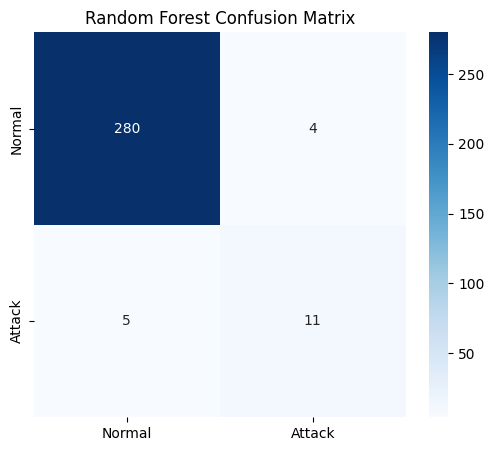

In [15]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Random Forest Confusion Matrix')
plt.show()

In [16]:
class RandomForestPipeline:
    """
    Complete Random Forest pipeline in ONE file
    - Contains: model, scaler, features, threshold
    """
    def __init__(self, model, scaler, feature_names, threshold):
        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.threshold = threshold
        self.name = "Random Forest"
        self.version = "1.0"
    
    def predict(self, features):
        features_scaled = self.scaler.transform([features])
        
        proba = self.model.predict_proba(features_scaled)[0][1]
        prediction = 1 if proba >= self.threshold else 0
        
        return {
            'prediction': 'Attack' if prediction == 1 else 'Normal',
            'probability': float(proba),
            'threshold': self.threshold,
            'model': self.name
        }
    
    def predict_proba(self, features):
        features_scaled = self.scaler.transform([features])
        return self.model.predict_proba(features_scaled)[0]
    
    def get_info(self):
        return {
            'model': self.name,
            'version': self.version,
            'threshold': self.threshold,
            'features': self.feature_names,
            'n_features': len(self.feature_names)
        }

feature_names = [
    'total_logons', 'avg_logon_hour', 'std_logon_hour', 
    'weekend_logons', 'after_hours_logons', 'unique_pcs_logon',
    'total_device_activities', 'unique_pcs_device', 
    'avg_device_hour', 'after_hours_device',
    'total_file_activities', 'unique_files', 'unique_pcs_file',
    'avg_file_hour', 'after_hours_files'
]

rf_pipeline = RandomForestPipeline(
    model=rf,
    scaler=scaler,
    feature_names=feature_names,
    threshold=0.35
)

joblib.dump(rf_pipeline, 'rf_complete_pipeline.pkl')
print("Random Forest complete pipeline saved as 'rf_complete_pipeline.pkl'")

Random Forest complete pipeline saved as 'rf_complete_pipeline.pkl'


importance Features 
1. unique_pcs_logon: 0.0095
2. weekend_logons: 0.0104
3. after_hours_device: 0.0118
4. unique_pcs_device: 0.0191
5. after_hours_files: 0.0203
6. after_hours_logons: 0.0229
7. total_logons: 0.0268
8. total_device_activities: 0.0537
9. avg_device_hour: 0.0610
10. std_logon_hour: 0.0671
11. avg_logon_hour: 0.0808
12. unique_files: 0.1066
13. avg_file_hour: 0.1674
14. unique_pcs_file: 0.1707
15. total_file_activities: 0.1719


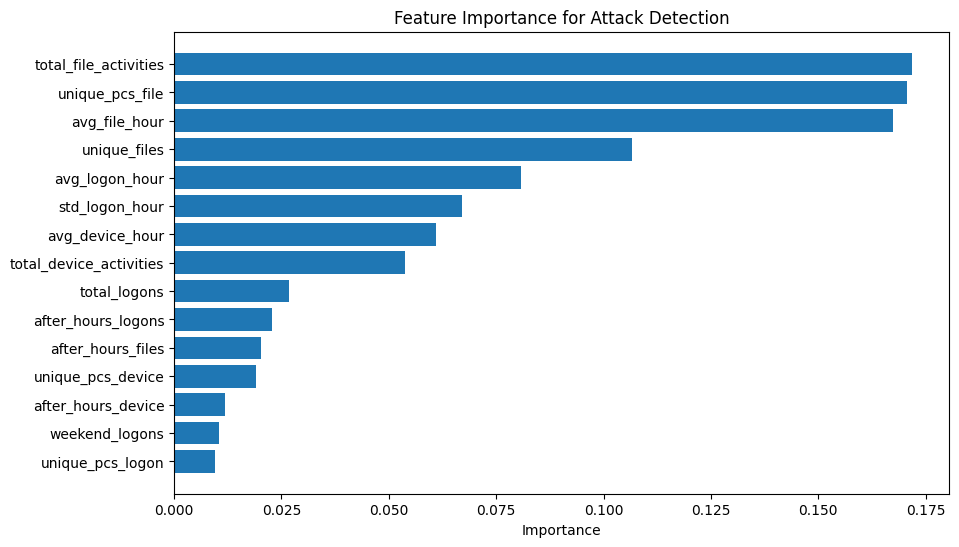

In [17]:
rf_model = joblib.load('rf_complete_pipeline.pkl')

importance = rf_model.model.feature_importances_
feature_names = rf_model.feature_names


indices = np.argsort(importance)

print("=" * 60)
print('importance Features ')
print("=" * 60)
for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]}: {importance[indices[i]]:.4f}")

plt.figure(figsize=(10,6))
plt.barh(range(len(feature_names)), importance[indices])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.title('Feature Importance for Attack Detection')
plt.show()

In [18]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    scale_pos_weight=5,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       284
      Attack       0.71      0.62      0.67        16

    accuracy                           0.97       300
   macro avg       0.85      0.81      0.82       300
weighted avg       0.96      0.97      0.97       300



In [19]:
class XGBoostPipeline:
    """
    Complete XGBoost pipeline in ONE file
    - Contains: model, features, threshold
    """
    def __init__(self, model, feature_names, threshold=0.5):
        self.model = model
        self.feature_names = feature_names
        self.threshold = threshold
        self.name = "XGBoost"
        self.version = "1.0"
    
    def predict(self, features):
        proba = self.model.predict_proba([features])[0][1]
        
        prediction = 1 if proba >= self.threshold else 0
        
        return {
            'prediction': 'Attack' if prediction == 1 else 'Normal',
            'probability': float(proba),
            'threshold': self.threshold,
            'model': self.name
        }
    
    def predict_proba(self, features):
        return self.model.predict_proba([features])[0]
    
    def get_info(self):
        return {
            'model': self.name,
            'version': self.version,
            'threshold': self.threshold,
            'features': self.feature_names,
            'n_features': len(self.feature_names)
        }

xgb_pipeline = XGBoostPipeline(
    model=xgb,
    feature_names=feature_names,
    threshold=0.5
)

joblib.dump(xgb_pipeline, 'xgb_complete_pipeline.pkl')
print("XGBoost complete pipeline saved as 'xgb_complete_pipeline.pkl'")

XGBoost complete pipeline saved as 'xgb_complete_pipeline.pkl'


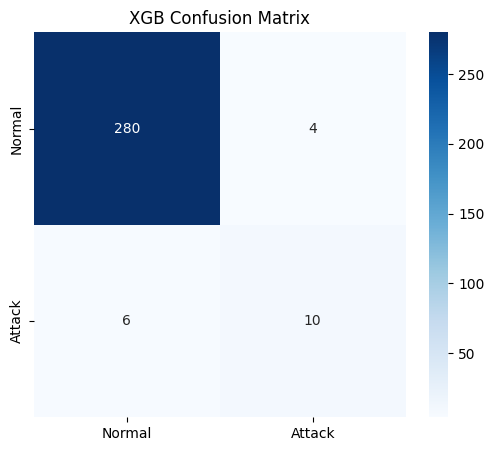

In [20]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('XGB Confusion Matrix')
plt.show()

## CNN

In [21]:
print(f"Original X shape: {X_user.shape}")

X_cnn = X_user.reshape(X_user.shape[0], 1, X_user.shape[1])
print(f"CNN input shape: {X_cnn.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_user, test_size=0.3, random_state=42, stratify=y_user
)

X_train_reshaped = X_train.reshape(-1, X_user.shape[1])
X_test_reshaped = X_test.reshape(-1, X_user.shape[1])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

X_train_cnn = X_train_scaled.reshape(-1, 1, X_user.shape[1])
X_test_cnn = X_test_scaled.reshape(-1, 1, X_user.shape[1])

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

Original X shape: (1000, 15)
CNN input shape: (1000, 1, 15)
X_train_cnn shape: (700, 1, 15)
X_test_cnn shape: (300, 1, 15)


In [22]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"Class weights:")
print(f"  Normal (0): {class_weight_dict[0]:.4f}")
print(f"  Attack (1): {class_weight_dict[1]:.4f}")

Class weights:
  Normal (0): 0.5287
  Attack (1): 9.2105


In [23]:
n_features = X_train_cnn.shape[2]  
print(f"Number of features: {n_features}")

model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, n_features)),
    BatchNormalization(),
    Dropout(0.3),
    
    Conv1D(filters=128, kernel_size=1, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Flatten(),
    
    Dense(64, activation='relu'),
    Dropout(0.4),
    
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])
model.summary()

Number of features: 15


C:\Users\pavilion\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,481 (80.00 KB)

 Trainable params: 20,097 (78.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=8,   
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - Precision: 0.0957 - Recall: 0.6452 - accuracy: 0.6429 - loss: 0.7206 - val_Precision: 0.2000 - val_Recall: 0.7143 - val_accuracy: 0.8429 - val_loss: 0.6322
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.1316 - Recall: 0.6452 - accuracy: 0.7446 - loss: 0.6264 - val_Precision: 0.1852 - val_Recall: 0.7143 - val_accuracy: 0.8286 - val_loss: 0.5818
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Precision: 0.1812 - Recall: 0.8065 - accuracy: 0.7875 - loss: 0.4445 - val_Precision: 0.2632 - val_Recall: 0.7143 - val_accuracy: 0.8857 - val_loss: 0.4287
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.1894 - Recall: 0.8065 - accuracy: 0.7982 - loss: 0.4555 - val_Precision: 0.2500 - val_Recall: 0.7143 - val_accuracy: 0.8786 - val_loss: 0.3181
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Precision: 0.2034 - Recall: 0.7742 - accuracy: 0.8196 - loss: 0.3955 - val_Precision: 0.3889 - val_Recall: 1.0

In [56]:
class CNNPipeline:
    """
    Complete CNN pipeline in ONE file
    - Contains: model, scaler, features, threshold
    """
    def __init__(self, model, scaler, feature_names, threshold=0.5):
        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.threshold = threshold
        self.name = "CNN"
        self.version = "1.0"
    
    def predict(self, features):
        features_scaled = self.scaler.transform([features])
        
        features_cnn = features_scaled.reshape(1, 1, -1)
        
        proba = self.model.predict(features_cnn, verbose=0)[0][0]
        
        prediction = 1 if proba >= self.threshold else 0
        
        return {
            'prediction': 'Attack' if prediction == 1 else 'Normal',
            'probability': float(proba),
            'threshold': self.threshold,
            'model': self.name
        }
    
    def get_info(self):
        return {
            'model': self.name,
            'version': self.version,
            'threshold': self.threshold,
            'features': self.feature_names,
            'n_features': len(self.feature_names)
        }

feature_names = [
    'total_logons', 'avg_logon_hour', 'std_logon_hour', 
    'weekend_logons', 'after_hours_logons', 'unique_pcs_logon',
    'total_device_activities', 'unique_pcs_device', 
    'avg_device_hour', 'after_hours_device',
    'total_file_activities', 'unique_files', 'unique_pcs_file',
    'avg_file_hour', 'after_hours_files'
]

cnn_pipeline = CNNPipeline(
    model=model,
    scaler=scaler,
    feature_names=feature_names,
    threshold=0.5
)

joblib.dump(cnn_pipeline, 'cnn_complete_pipeline.pkl')
print("CNN pipeline saved as 'cnn_complete_pipeline.pkl'")

model.save('cnn_weights.h5')
print(" CNN weights saved as 'cnn_weights.h5'")

CNN pipeline saved as 'cnn_complete_pipeline.pkl'
 CNN weights saved as 'cnn_weights.h5'


### Validation


1. Identifying duplicate samples...
Found 442 rows with duplicates!

Sample of duplicates:
       0          1         2    3     4    5    6    7    8    9   10   11  \
0   30.0  13.000000  7.071068  0.0   0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
2   30.0  12.500000  6.363961  0.0   0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
3   30.0  11.500000  6.363961  0.0  15.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
5   30.0  13.500000  7.778175  0.0  15.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
7   30.0  12.666667  7.165349  0.0   6.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
11  30.0  11.500000  6.363961  0.0  15.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
17  30.0  13.500000  7.778175  0.0  15.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
19  30.0  13.500000  7.778175  0.0  15.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
20  30.0  12.500000  7.778175  0.0  15.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
21  29.0  14.600000  7.919596  0.0  14.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   

     12   13   14  temp_id  target  
0

C:\Users\pavilion\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7468 - auc_14: 0.8231 - loss: 0.5865 - precision_17: 0.7277 - recall_17: 0.7888 - val_accuracy: 0.8495 - val_auc_14: 0.9382 - val_loss: 0.6291 - val_precision_17: 0.3636 - val_recall_17: 1.0000 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8880 - auc_14: 0.9421 - loss: 0.3057 - precision_17: 0.8588 - recall_17: 0.9288 - val_accuracy: 0.7849 - val_auc_14: 0.9404 - val_loss: 0.5717 - val_precision_17: 0.2857 - val_recall_17: 1.0000 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9198 - auc_14: 0.9692 - loss: 0.2121 - precision_17: 0.9044 - recall_17: 0.9389 - val_accuracy: 0.9032 - val_auc_14: 0.9551 - val_loss: 0.5503 - val_precision_17: 0.4706 - val_recall_17: 1.0000 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9466 - auc_14: 0.9771 - loss: 0.1731 - precision_17: 0.9249 - recall_17: 0.9720 - val_accuracy: 0

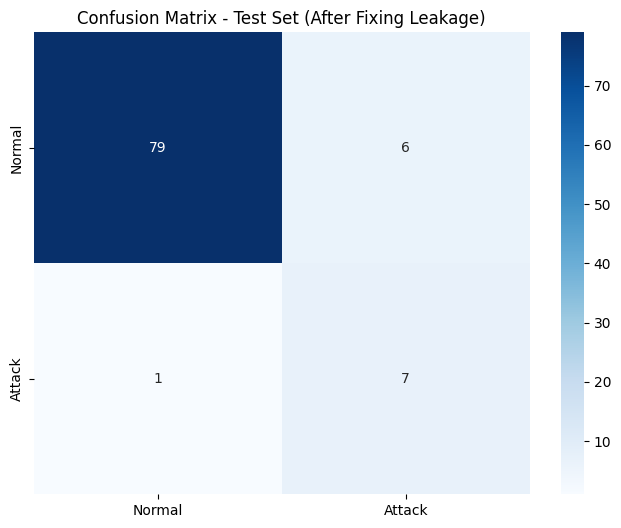

In [99]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import tensorflow as tf

print("\n1. Identifying duplicate samples...")

X_df = pd.DataFrame(X_user)
y_df = pd.Series(y_user, name='target')

X_df['temp_id'] = range(len(X_df))
X_df['target'] = y_df

duplicated_rows = X_df[X_df.iloc[:, :-2].duplicated(keep=False)]
if len(duplicated_rows) > 0:
    print(f"Found {len(duplicated_rows)} rows with duplicates!")
    print("\nSample of duplicates:")
    print(duplicated_rows.head(10))
else:
    print("No exact duplicates found in features.")

print("\n2. Removing duplicates while preserving one instance per unique sample...")

X_unique = X_df.drop_duplicates(subset=X_df.columns[:-2], keep='first')
print(f"Original shape: {X_df.shape}")
print(f"After removing duplicates: {X_unique.shape}")
print(f"Removed {len(X_df) - len(X_unique)} duplicate samples")

X_clean = X_unique.iloc[:, :-2].values
y_clean = X_unique['target'].values

print("\n3. Splitting data with stratification...")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean, y_clean, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_clean,
    shuffle=True,
    )

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp,
    shuffle=True
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples") 
print(f"Test set: {len(X_test)} samples")

print("\n4. Verifying no leakage between sets...")

def check_overlap(set1, set2, name1, name2):
    set1_tuples = set(tuple(row) for row in set1)
    set2_tuples = set(tuple(row) for row in set2)
    
    overlap = set1_tuples.intersection(set2_tuples)
    
    if len(overlap) > 0:
        print(f" ERROR: {len(overlap)} samples are identical between {name1} and {name2}!")
        return False
    else:
        print(f" No identical samples between {name1} and {name2}")
        return True

check_overlap(X_train, X_val, "Training", "Validation")
check_overlap(X_train, X_test, "Training", "Test")
check_overlap(X_val, X_test, "Validation", "Test")

print("\n5. Applying SMOTE to training data only...")

X_train_2d = X_train.reshape(X_train.shape[0], -1)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_2d, y_train)

print(f"Before SMOTE - Training: {X_train_2d.shape}, Normal: {sum(y_train==0)}, Attack: {sum(y_train==1)}")
print(f"After SMOTE - Training: {X_train_balanced.shape}, Normal: {sum(y_train_balanced==0)}, Attack: {sum(y_train_balanced==1)}")

print("\n6. Normalizing data...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training scaled - mean: {np.mean(X_train_scaled):.4f}, std: {np.std(X_train_scaled):.4f}")
print(f"Validation scaled - mean: {np.mean(X_val_scaled):.4f}, std: {np.std(X_val_scaled):.4f}")

print("\n7. Reshaping for CNN...")

n_features = X_user.shape[1]
X_train_final = X_train_scaled.reshape(-1, n_features, 1)
X_val_final = X_val_scaled.reshape(-1, n_features, 1)
X_test_final = X_test_scaled.reshape(-1, n_features, 1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_val_final shape: {X_val_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

print("\n8. Final verification - no leakage check...")

X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
X_val_flat = X_val_final.reshape(X_val_final.shape[0], -1)

from sklearn.metrics.pairwise import euclidean_distances
distances = euclidean_distances(X_val_flat[:50], X_train_flat[:200])  # فحص عينة
min_distances = np.min(distances, axis=1)

print(f"Minimum distances (Validation to Training):")
print(f"  Mean: {np.mean(min_distances):.6f}")
print(f"  Min: {np.min(min_distances):.6f}")

if np.min(min_distances) < 1e-10:
    print(" ERROR: Still found identical samples!")
else:
    print(" No identical samples found - ready to train!")


model_fixed = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_features, 1), padding='same'),
    BatchNormalization(),
    Dropout(0.3),
    
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),
    
    Flatten(),
    
    Dense(64, activation='relu'),
    Dropout(0.4),
    
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

model_fixed.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)


history_fixed = model_fixed.fit(
    X_train_final, y_train_balanced,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_final, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n" + "="*60)
print("FINAL EVALUATION (NO LEAKAGE)")
print("="*60)

test_results = model_fixed.evaluate(X_test_final, y_test, verbose=0)
print("\nTest Set Results (Real performance):")
for name, value in zip(model_fixed.metrics_names, test_results):
    print(f"  {name}: {value:.4f}")

y_pred_prob = model_fixed.predict(X_test_final)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Test Set (After Fixing Leakage)')
plt.show()

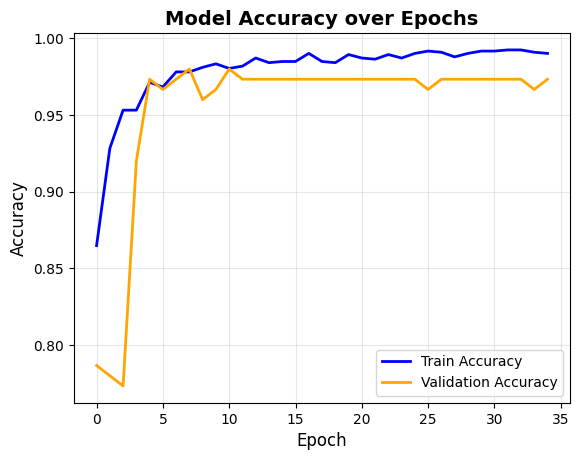

In [100]:
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
plt.title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

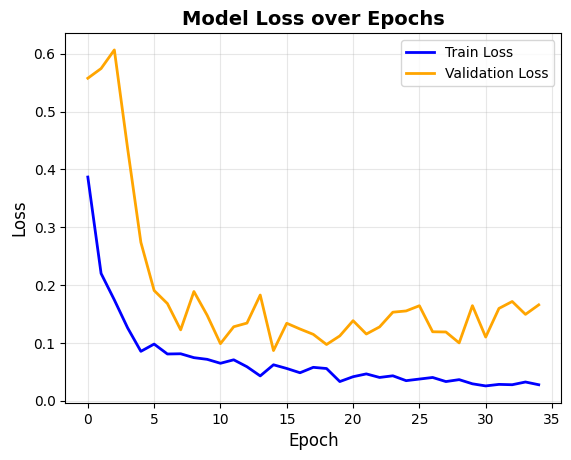

In [101]:
plt.plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
plt.title('Model Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)